<a href="https://colab.research.google.com/github/sonaha135-create/project1/blob/main/social_media_content_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import  seaborn as sns


In [ ]:
df = pd.read_excel("/content/social media sql.xlsx")

In [ ]:
df.head(5)

,Post_ID,Platform,Post_Date,Content_Type,Category,Caption_Length,Hashtag_Count,Video_Length_Sec,Follower_Count,Reach,Impressions,Likes,Comments,Shares,Saves
0,P10000,YT,2025-02-17 14:00:00,Image,Fashion,373.0,9.0,NaN,22833,11748.0,12882,306.0,26,13,5
1,P10001,Instagram,2025-03-01 01:00:00,Video,Food,59.0,13.0,93.0,101421,116800.0,199846,3899.0,342,227,47
2,P10002,Facebook,2025-08-06 06:00:00,Reel,Technology,108.0,7.0,23.0,76347,38075.0,58366,1988.0,104,185,41
3,P10003,Instagram,2025-02-23 15:00:00,Reel,Travel,144.0,7.0,123.0,79155,43815.0,63419,1950.0,154,31,10
4,P10004,Instagram,2025-03-12 21:00:00,Image,Fashion,469.0,13.0,NaN,356935,69894.0,94410,1217.0,87,43,9


In [ ]:
print("rows:",df.shape[0])
print("cloumns:", df.shape[1])

rows: 2012
cloumns: 15


In [ ]:
display(df.head(10))

,Post_ID,Platform,Post_Date,Content_Type,Category,Caption_Length,Hashtag_Count,Video_Length_Sec,Follower_Count,Reach,Impressions,Likes,Comments,Shares,Saves
0,P10000,YT,2025-02-17 14:00:00,Image,Fashion,373.0,9.0,NaN,22833,11748.0,12882,306.0,26,13,5
1,P10001,Instagram,2025-03-01 01:00:00,Video,Food,59.0,13.0,93.0,101421,116800.0,199846,3899.0,342,227,47
2,P10002,Facebook,2025-08-06 06:00:00,Reel,Technology,108.0,7.0,23.0,76347,38075.0,58366,1988.0,104,185,41
3,P10003,Instagram,2025-02-23 15:00:00,Reel,Travel,144.0,7.0,123.0,79155,43815.0,63419,1950.0,154,31,10
4,P10004,Instagram,2025-03-12 21:00:00,Image,Fashion,469.0,13.0,NaN,356935,69894.0,94410,1217.0,87,43,9
5,P10005,Instagram,2025-06-20 11:00:00,Reel,Gaming,437.0,6.0,125.0,226580,68533.0,111207,3546.0,339,154,0
6,P10006,YouTube,2025-02-21 09:00:00,Image,Entertainment,493.0,5.0,NaN,411743,214810.0,345006,20686.0,3036,404,550
7,P10007,LinkedIn,2025-04-13 05:00:00,Reel,Technology,370.0,3.0,21.0,456355,305808.0,477782,47738.0,917,155,451
8,P10008,LinkedIn,2025-11-12 02:00:00,Image,Beauty,28.0,0.0,NaN,119527,14325.0,15814,1645.0,58,30,28
9,P10009,Facebook,2025-11-15 12:00:00,Video,Technology,369.0,14.0,146.0,234482,54767.0,88040,8726.0,949,97,92


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2012 entries, 0 to 2011
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Post_ID           2012 non-null   object        
 1   Platform          2012 non-null   object        
 2   Post_Date         2012 non-null   datetime64[ns]
 3   Content_Type      2012 non-null   object        
 4   Category          2012 non-null   object        
 5   Caption_Length    1988 non-null   float64       
 6   Hashtag_Count     1992 non-null   float64       
 7   Video_Length_Sec  1129 non-null   float64       
 8   Follower_Count    2012 non-null   int64         
 9   Reach             1996 non-null   float64       
 10  Impressions       2012 non-null   int64         
 11  Likes             2000 non-null   float64       
 12  Comments          2012 non-null   int64         
 13  Shares            2012 non-null   int64         
 14  Saves             2012 n

In [ ]:
df.isnull().sum()

,0
Post_ID,0
Platform,0
Post_Date,0
Content_Type,0
Category,0
Caption_Length,24
Hashtag_Count,20
Video_Length_Sec,883
Follower_Count,0
Reach,16


In [ ]:
df.duplicated().sum()

np.int64(11)

In [ ]:
print(df["Platform"].unique())
print(df["Content_Type"].unique())
print(df["Category"].unique())

['YT' 'Instagram' 'Facebook' 'YouTube' 'LinkedIn' 'linkedin' 'instagram'
 'IG' 'facebook' 'youtube' 'Linkedin' 'FB']
['Image' 'Video' 'Reel' 'Carousel' 'Story']
['Fashion' 'Food' 'Technology' 'Travel' 'Gaming' 'Entertainment' 'Beauty'
 'Lifestyle' 'Education' 'Fitness']


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
Video_Length_Sec,883
Caption_Length,24
Hashtag_Count,20
Reach,16
Likes,12
Post_Date,0
Post_ID,0
Content_Type,0
Category,0
Platform,0


In [ ]:
df.shape

(2012, 15)

In [ ]:
df[df["Hashtag_Count"]<0]

,Post_ID,Platform,Post_Date,Content_Type,Category,Caption_Length,Hashtag_Count,Video_Length_Sec,Follower_Count,Reach,Impressions,Likes,Comments,Shares,Saves
38,P10038,YouTube,2025-01-14 09:00:00,Image,Food,490.0,-1.0,NaN,174668,53294.0,69578,1289.0,112,43,6
379,P10379,YouTube,2025-06-18 07:00:00,Reel,Fashion,455.0,-1.0,152.0,206671,155760.0,184349,16241.0,1031,503,392
557,P10557,Instagram,2025-10-09 17:00:00,Image,Fashion,151.0,-1.0,NaN,416676,175946.0,277195,21640.0,2644,630,500
620,P10620,Instagram,2025-02-16 11:00:00,Video,Beauty,396.0,-1.0,172.0,236120,118997.0,198521,7818.0,552,62,88
1889,P11889,Instagram,2025-05-18 21:00:00,Image,Fitness,51.0,-1.0,NaN,245776,85717.0,101699,2316.0,94,82,21


In [ ]:
numeric_cols = df.select_dtypes(include="number").columns

In [ ]:
(df[numeric_cols]<0).sum().sort_values(ascending=False)

,0
Hashtag_Count,5
Caption_Length,0
Video_Length_Sec,0
Follower_Count,0
Reach,0
Impressions,0
Likes,0
Comments,0
Shares,0
Saves,0


In [ ]:
df_clean = df.copy()

In [ ]:
df_clean = df_clean.drop_duplicates()

In [ ]:
df_clean.shape

(2001, 15)

In [ ]:
df_clean["Platform"].value_counts()

,count
Platform,
Instagram,939
YouTube,417
Facebook,358
LinkedIn,228
IG,16
instagram,13
YT,8
FB,6
linkedin,5


In [ ]:
platform_performance={
    "instagram":"Instagram",
    "IG":"Instagram",
    "facebook":"Facebook",
    "FB":"Facebook",
    "youtube":"YouTube",
    "YT":"YouTube",
    "linkedin":"LinkedIn",
    "Linkedin":"LinkedIn"


}
df_clean["Platform"] = df_clean["Platform"].replace(platform_performance)

In [ ]:
df_clean = df_clean.drop_duplicates()

In [ ]:
df_clean.loc[df_clean["Hashtag_Count"]<0,"Hashtag_Count"]=np.nan

In [ ]:
df_clean["Performance_data_Complete"]=(
    df_clean["Reach"].notna() &
    df_clean["Likes"].notna()

)

In [ ]:
df_clean[df_clean["Video_Length_Sec"].isna()]["Content_Type"].value_counts()

,count
Content_Type,
Image,492
Carousel,367
Video,8
Reel,8
Story,1


In [ ]:
df_clean[df_clean["Reach"].isna()][
    ["Post_ID","Platform","Content_Type","Category","Impressions","Likes"]
]

,Post_ID,Platform,Content_Type,Category,Impressions,Likes
261,P10261,YouTube,Video,Fashion,314318,28202.0
342,P10342,Instagram,Video,Technology,97924,9755.0
350,P10350,Instagram,Image,Lifestyle,7490,163.0
401,P10401,YouTube,Reel,Beauty,45582,4258.0
421,P10421,Instagram,Image,Entertainment,8134,299.0
475,P10475,Facebook,Video,Beauty,221009,27916.0
514,P10514,Facebook,Image,Entertainment,153535,3968.0
517,P10517,Facebook,Video,Gaming,10872,284.0
882,P10882,Instagram,Image,Education,170212,4752.0
1371,P11371,LinkedIn,Reel,Gaming,78285,4937.0


In [ ]:
df_clean[df_clean["Likes"].isna()][
    ["Post_ID","Platform","Content_Type","Category","Impressions","Likes"]
]

,Post_ID,Platform,Content_Type,Category,Impressions,Likes
621,P10621,Instagram,Carousel,Education,122014,NaN
663,P10663,YouTube,Carousel,Lifestyle,176699,NaN
688,P10688,YouTube,Carousel,Technology,339404,NaN
768,P10768,Instagram,Image,Food,185631,NaN
1207,P11207,Facebook,Image,Education,83715,NaN
1212,P11212,LinkedIn,Reel,Technology,13225,NaN
1303,P11303,YouTube,Reel,Travel,398828,NaN
1440,P11440,Instagram,Video,Gaming,240425,NaN
1562,P11562,YouTube,Reel,Travel,377312,NaN
1643,P11643,YouTube,Image,Entertainment,70092,NaN


In [ ]:
df_clean["Performance_data_Complete"].value_counts()

,count
Performance_data_Complete,
True,1972
False,28


In [ ]:
df_clean[df_clean["Video_Length_Sec"].isna()]["Content_Type"].value_counts()

,count
Content_Type,
Image,492
Carousel,367
Video,8
Reel,8
Story,1


In [ ]:
df_clean[df_clean["Video_Length_Sec"].isna() &
         df_clean["Content_Type"].isin(["Video","Reel","Story"])
         ][
    ["Post_ID","Platform","Content_Type","Category","Reach","Likes"]
]

,Post_ID,Platform,Content_Type,Category,Reach,Likes
34,P10034,Instagram,Video,Fashion,162107.0,4741.0
124,P10124,LinkedIn,Video,Entertainment,125434.0,13732.0
270,P10270,LinkedIn,Video,Education,97445.0,2549.0
493,P10493,Facebook,Reel,Gaming,192109.0,10567.0
517,P10517,Facebook,Video,Gaming,NaN,284.0
674,P10674,Facebook,Reel,Fitness,114977.0,11869.0
830,P10830,Facebook,Video,Beauty,31784.0,3337.0
908,P10908,LinkedIn,Reel,Fashion,22064.0,1509.0
1086,P11086,YouTube,Story,Food,400696.0,42637.0
1101,P11101,Instagram,Reel,Lifestyle,152498.0,12620.0


In [ ]:
df_clean["Is_Video_Content"] = df_clean["Content_Type"].isin(["Video","Reel","Story"])

In [ ]:
df_clean["Is_Video_Content"].value_counts()

,count
Is_Video_Content,
True,1141
False,859


In [ ]:
df_clean["Is_Video_Content"] = df_clean["Content_Type"].isin(["Video","Reel"])

In [ ]:
print("Shape:",df_clean.shape)
print("Duplicates", df_clean.duplicated().sum())
print("Negative hashtags:", (df_clean["Hashtag_Count"]<0).sum())
print("\nPlatforms")
print(df_clean["Platform"].unique())

Shape: (2000, 17)
Duplicates 0
Negative hashtags: 0

Platforms
['YouTube' 'Instagram' 'Facebook' 'LinkedIn']


In [ ]:
top_likes = df.nlargest(10, 'Likes')

top_likes

,Post_ID,Platform,Post_Date,Content_Type,Category,Caption_Length,Hashtag_Count,Video_Length_Sec,Follower_Count,Reach,Impressions,Likes,Comments,Shares,Saves
12,P10012,YouTube,2025-04-06 07:00:00,Reel,Fashion,496.0,14.0,94.0,203511,369639.0,492052,81037.0,4227,642,332
450,P10450,Instagram,2025-02-06 15:00:00,Reel,Beauty,287.0,0.0,94.0,424617,351175.0,539185,61348.0,4220,2031,1549
1526,P11526,YouTube,2025-04-12 12:00:00,Image,Technology,45.0,5.0,NaN,435123,484165.0,520521,53911.0,1436,1170,800
861,P10861,YouTube,2025-12-09 05:00:00,Video,Fashion,175.0,5.0,132.0,418437,287622.0,392647,51470.0,1188,631,300
1111,P11111,Instagram,2025-07-25 12:00:00,Reel,Technology,105.0,8.0,128.0,452158,412360.0,479655,50924.0,4237,952,791
258,P10258,YouTube,2025-12-17 20:00:00,Video,Lifestyle,202.0,11.0,68.0,497958,364689.0,568401,50679.0,6048,441,290
1348,P11348,YouTube,2025-12-17 04:00:00,Reel,Education,208.0,2.0,132.0,446441,303900.0,519838,50417.0,3480,629,141
232,P10232,Instagram,2025-01-15 17:00:00,Reel,Fashion,239.0,7.0,91.0,457282,461328.0,504897,50382.0,3090,3072,263
756,P10756,YouTube,2025-03-25 10:00:00,Reel,Entertainment,201.0,8.0,61.0,393690,568476.0,897494,49729.0,5342,1355,2107
980,P10980,Instagram,2025-09-02 15:00:00,Reel,Fitness,187.0,7.0,127.0,487010,330662.0,421489,49204.0,2403,2017,365


In [ ]:
top_comments = df.nlargest(10, 'Comments')
top_comments


,Post_ID,Platform,Post_Date,Content_Type,Category,Caption_Length,Hashtag_Count,Video_Length_Sec,Follower_Count,Reach,Impressions,Likes,Comments,Shares,Saves
258,P10258,YouTube,2025-12-17 20:00:00,Video,Lifestyle,202.0,11.0,68.0,497958,364689.0,568401,50679.0,6048,441,290
756,P10756,YouTube,2025-03-25 10:00:00,Reel,Entertainment,201.0,8.0,61.0,393690,568476.0,897494,49729.0,5342,1355,2107
1970,P11970,Instagram,2025-05-21 23:00:00,Reel,Food,221.0,7.0,140.0,404547,262331.0,458937,43374.0,4572,1102,241
1722,P11722,YouTube,2025-01-05 04:00:00,Reel,Beauty,178.0,14.0,53.0,290410,186283.0,300015,40314.0,4440,978,519
1111,P11111,Instagram,2025-07-25 12:00:00,Reel,Technology,105.0,8.0,128.0,452158,412360.0,479655,50924.0,4237,952,791
12,P10012,YouTube,2025-04-06 07:00:00,Reel,Fashion,496.0,14.0,94.0,203511,369639.0,492052,81037.0,4227,642,332
450,P10450,Instagram,2025-02-06 15:00:00,Reel,Beauty,287.0,0.0,94.0,424617,351175.0,539185,61348.0,4220,2031,1549
107,P10107,Instagram,2025-06-12 10:00:00,Reel,Education,279.0,3.0,29.0,379909,250633.0,306037,28451.0,4200,1240,785
1574,P11574,YouTube,2025-03-11 06:00:00,Image,Food,210.0,11.0,NaN,488261,370966.0,420409,29166.0,4020,1784,49
647,P10647,Instagram,2025-05-06 14:00:00,Video,Education,466.0,7.0,63.0,416645,225344.0,277221,27961.0,3969,200,486


In [ ]:
top_shares = df.nlargest(10, 'Shares')
top_shares

,Post_ID,Platform,Post_Date,Content_Type,Category,Caption_Length,Hashtag_Count,Video_Length_Sec,Follower_Count,Reach,Impressions,Likes,Comments,Shares,Saves
232,P10232,Instagram,2025-01-15 17:00:00,Reel,Fashion,239.0,7.0,91.0,457282,461328.0,504897,50382.0,3090,3072,263
683,P10683,IG,2025-09-08 04:00:00,Video,Technology,51.0,1.0,138.0,390417,235259.0,345121,35981.0,1120,3027,166
21,P10021,Instagram,2025-10-04 17:00:00,Reel,Gaming,255.0,4.0,175.0,427075,348657.0,406213,25347.0,1562,2918,6
1749,P11749,Instagram,2025-11-27 14:00:00,Reel,Entertainment,161.0,6.0,75.0,471860,320611.0,375873,45828.0,2809,2837,1894
1064,P11064,Facebook,2025-12-22 06:00:00,Reel,Lifestyle,432.0,3.0,66.0,252368,336537.0,583121,47279.0,2467,2587,2140
426,P10426,Instagram,2025-10-23 15:00:00,Video,Gaming,294.0,3.0,42.0,405289,943845.0,1898563,29362.0,1024,2449,659
1907,P11907,Facebook,2025-10-07 10:00:00,Video,Entertainment,418.0,4.0,99.0,396500,464232.0,976563,15510.0,768,2228,475
1457,P11457,YouTube,2025-07-18 11:00:00,Reel,Beauty,127.0,9.0,28.0,453149,632683.0,919037,22493.0,2858,2227,1670
504,P10504,Instagram,2025-11-04 00:00:00,Reel,Lifestyle,206.0,3.0,159.0,286253,220010.0,348480,26609.0,2460,2192,75
378,P10378,YouTube,2025-04-14 01:00:00,Video,Food,228.0,15.0,118.0,456142,366197.0,419302,48679.0,1085,2115,129


In [ ]:
# Create total engagement
df['total_engagement'] = (
    df['Likes'] +
    df['Comments'] +
    df['Shares'] +
    df['Saves']
)

# Create engagement rate
df['engagement_rate'] = (
    df['total_engagement'] / df['Reach']
) * 100

# Check the columns
df[['total_engagement', 'engagement_rate']].head()

,total_engagement,engagement_rate
0,350.0,2.979231
1,4515.0,3.865582
2,2318.0,6.087984
3,2145.0,4.895584
4,1356.0,1.940081


In [ ]:
# Clean and standardize Platform column

df['Platform'] = (
    df['Platform']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Convert all variations into standard names
df['Platform'] = df['Platform'].replace({
    'fb': 'Facebook',
    'facebook': 'Facebook',

    'ig': 'Instagram',
    'instagram': 'Instagram',

    'linkedin': 'LinkedIn',
    'linked in': 'LinkedIn',

    'yt': 'YouTube',
    'youtube': 'YouTube'
})

# Check the unique values
print(df['Platform'].unique())

['YouTube' 'Instagram' 'Facebook' 'LinkedIn']


In [ ]:
platform_performance = df.groupby('Platform').agg(
    avg_reach=('Reach', 'mean'),
    avg_impressions=('Impressions', 'mean'),
    avg_engagement=('total_engagement', 'mean'),
    avg_engagement_rate=('engagement_rate', 'mean'),
    total_engagement=('total_engagement', 'sum')
).round(2)
platform_performance

,avg_reach,avg_impressions,avg_engagement,avg_engagement_rate,total_engagement
Platform,,,,,
Facebook,85621.57,122655.78,5845.20,7.06,2151033.0
Instagram,123279.15,174250.44,8014.28,6.49,7773854.0
LinkedIn,67130.17,94629.67,5239.70,6.87,1231330.0
YouTube,167683.38,237701.28,11652.74,6.80,4975720.0


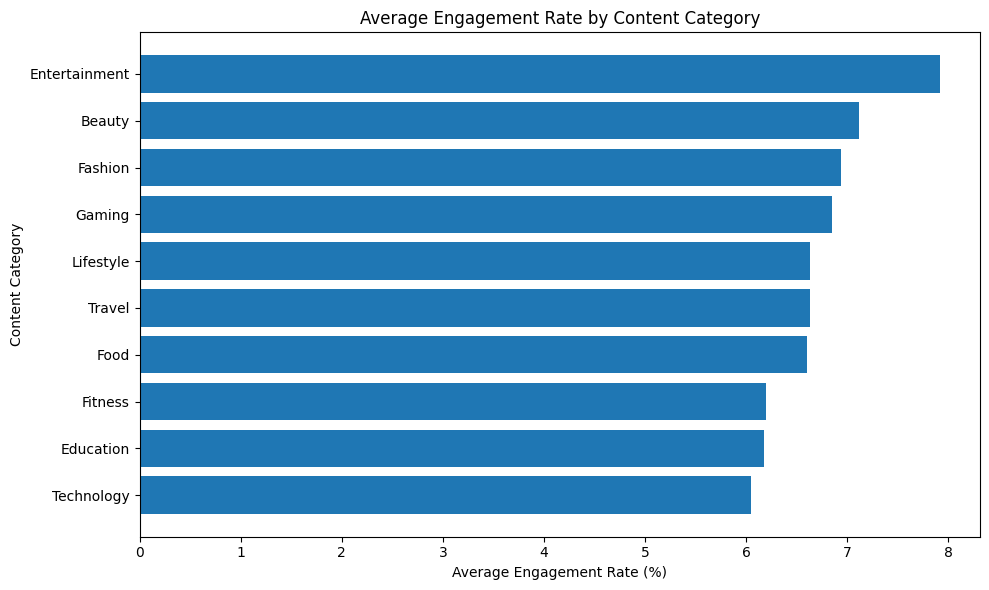

In [ ]:
category_performance = (
    df.groupby('Category')['engagement_rate']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.barh(
    category_performance.index,
    category_performance.values
)

plt.xlabel('Average Engagement Rate (%)')
plt.ylabel('Content Category')
plt.title('Average Engagement Rate by Content Category')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

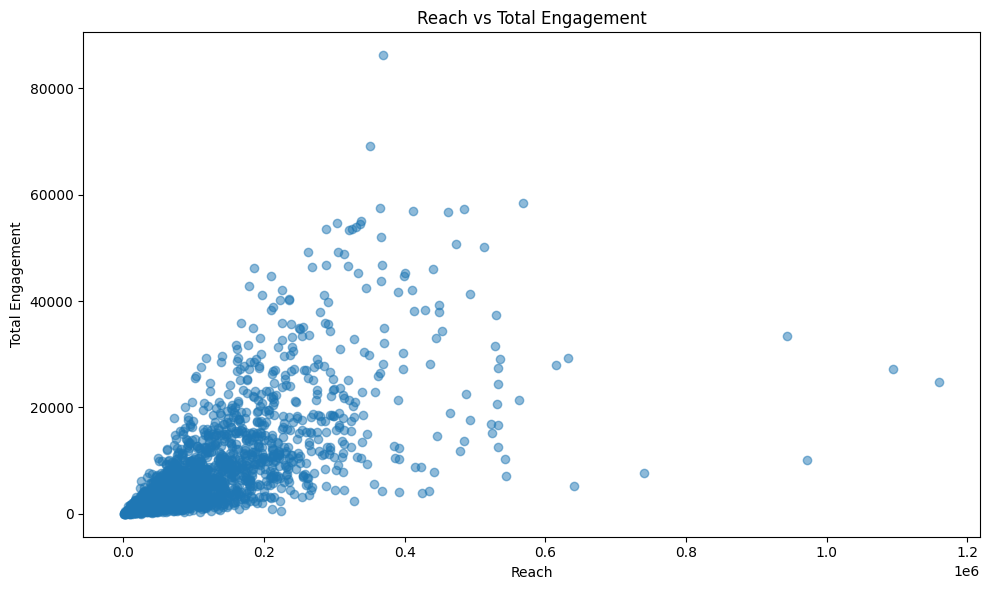

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['Reach'],
    df['total_engagement'],
    alpha=0.5
)

plt.xlabel('Reach')
plt.ylabel('Total Engagement')
plt.title('Reach vs Total Engagement')

plt.tight_layout()
plt.show()

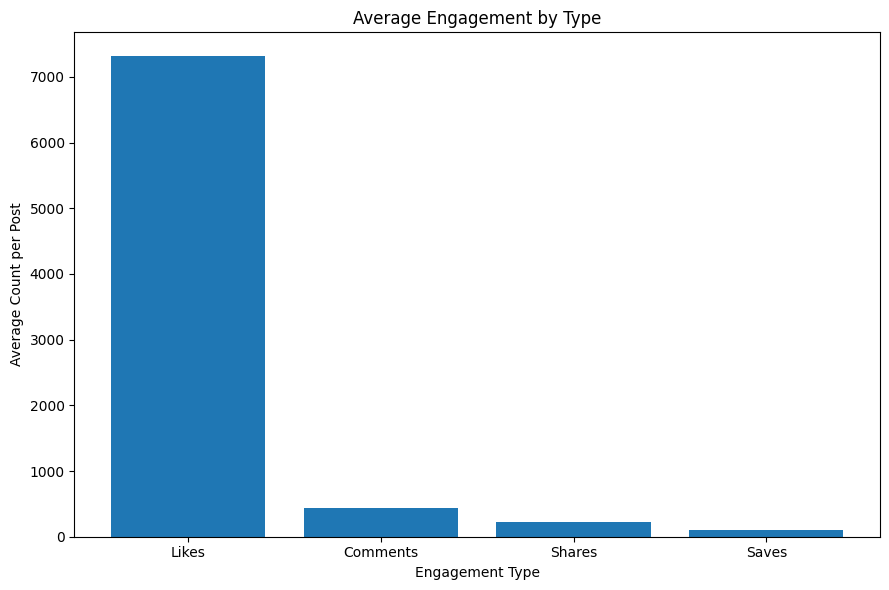

In [ ]:
engagement_metrics = [
    'Likes',
    'Comments',
    'Shares',
    'Saves'
]

average_engagement = df[engagement_metrics].mean()

plt.figure(figsize=(9, 6))

plt.bar(
    average_engagement.index,
    average_engagement.values
)

plt.xlabel('Engagement Type')
plt.ylabel('Average Count per Post')
plt.title('Average Engagement by Type')

plt.tight_layout()
plt.show()

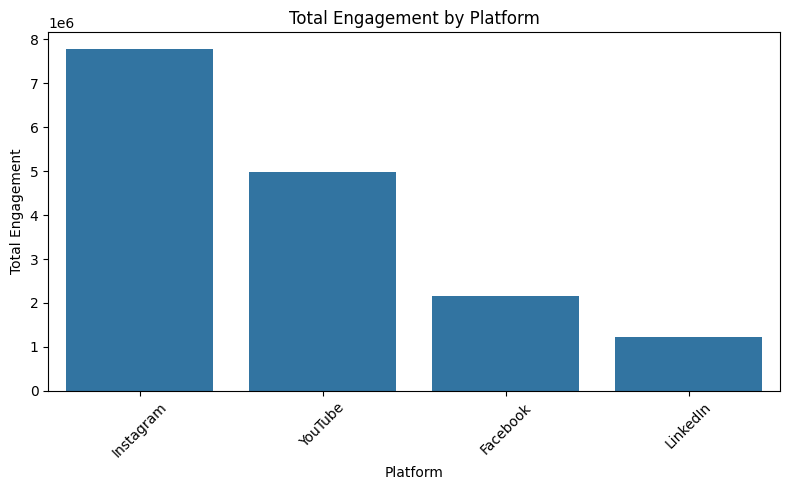

In [ ]:
platform_engagement = (
    df.groupby('Platform')['total_engagement']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
sns.barplot(
    x=platform_engagement.index,
    y=platform_engagement.values
)

plt.title('Total Engagement by Platform')
plt.xlabel('Platform')
plt.ylabel('Total Engagement')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

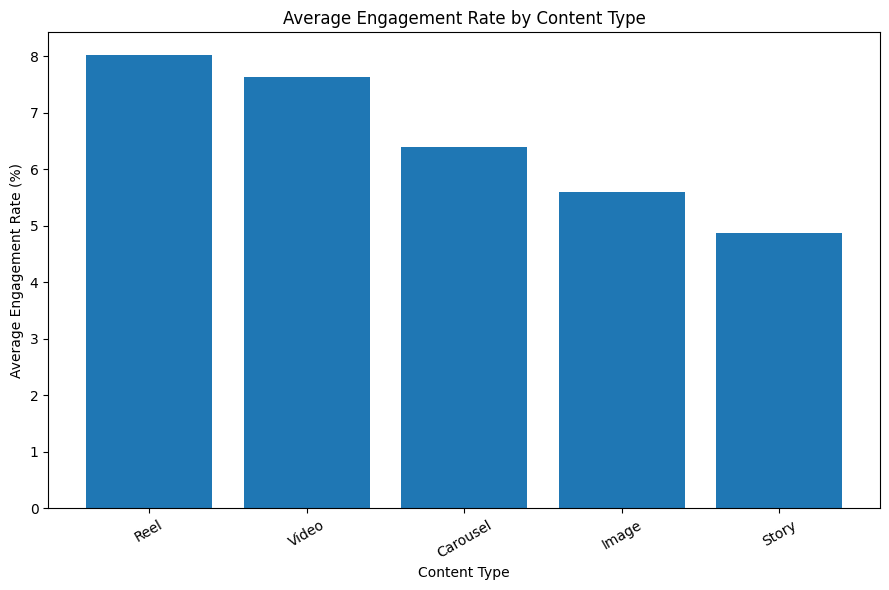

In [ ]:
content_performance = (
    df.groupby('Content_Type')['engagement_rate']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))

plt.bar(
    content_performance.index,
    content_performance.values
)

plt.xlabel('Content Type')
plt.ylabel('Average Engagement Rate (%)')
plt.title('Average Engagement Rate by Content Type')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
for name, value in globals().items():
    if hasattr(value, "shape:"):
        print(name,value.shape)

In [ ]:
from google.colab import files
df_clean.to_csv('social_media_data.csv', index=False)
files.download('social_media_data.csv')
df.shape

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

(2012, 17)

In [ ]:
df.columns.tolist()

['Post_ID',
 'Platform',
 'Post_Date',
 'Content_Type',
 'Category',
 'Caption_Length',
 'Hashtag_Count',
 'Video_Length_Sec',
 'Follower_Count',
 'Reach',
 'Impressions',
 'Likes',
 'Comments',
 'Shares',
 'Saves',
 'total_engagement',
 'engagement_rate']